In [ ]:
import numpy as np# type: ignore
import scipy as sp# type: ignore
import pandas as pd# type: ignore
import matplotlib.pyplot as plt# type: ignore
import sys
sys.path.append('/Users/leonardosantoro/Documents/GitHub/RiemannianEB/src')
from utils import *
from tqdm import tqdm
import seaborn as sns# type: ignore
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})
tau2 = 0.05
def sample_G(n_samples, tau2 = tau2): 
    circle = Hypersphere(1)
    mean1 = np.array([1./np.sqrt(2), 1./np.sqrt(2)])
    mean2 = -mean1
    classes = np.random.randint(0,2,n_samples).reshape(-1,1)
    samples1 = circle.random_riemannian_normal(mean1, 1./tau2, n_samples)
    samples2 = circle.random_riemannian_normal(mean2, 1./tau2, n_samples)
    return classes*samples1 + (1-classes)*samples2


# Set Parameters

In [19]:
n_samples = 1000
sigma2 = .2
M = 5
rho = 1e-2

# Visualisation

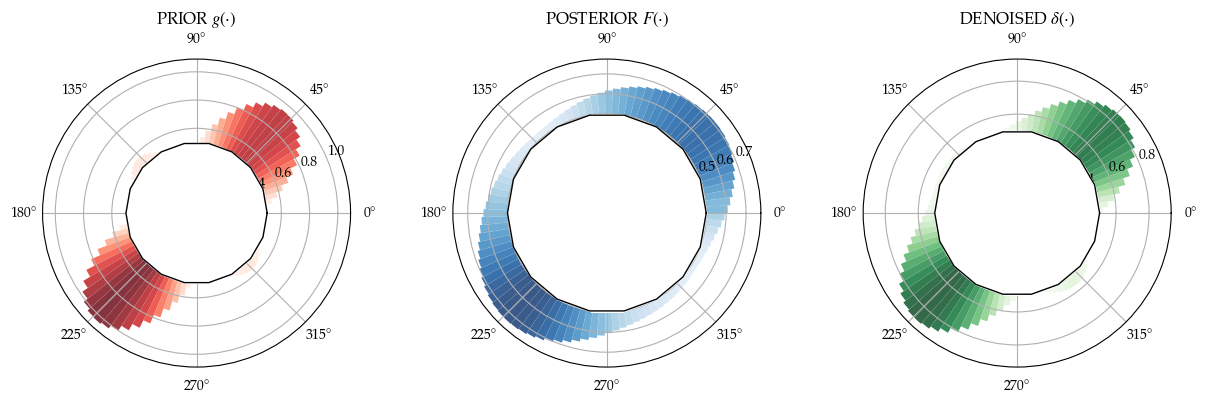

In [ ]:

f_scale = 0.3
res = 100
bottom = .5
incr = 20
angs = np.radians(np.arange(0, 360, incr))
angs_fill = np.append(angs, 2*np.pi)  # add 360 deg in radians
bottom_fill = np.append(bottom*np.ones_like(angs), bottom)
grid_I = np.linspace(0, 2*np.pi, 100)
grid = np.asarray([np.cos(grid_I),np.sin(grid_I)]).T
circle = Hypersphere(1)

fig = plt.figure(figsize=(15, 4))
#  G -----------------------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 1, polar=True)
Theta = sample_G(1000)
grid, hat_f, hat_grad_f = density_estimate('S1', Theta, M,  grid)
hat_f_pos = np.maximum(hat_f, 0); norm_hat_f = hat_f_pos / np.max(hat_f_pos)
ax1.bar(grid_I, f_scale*hat_f_pos, width=2*np.pi/res, bottom=bottom, color=plt.colormaps['Reds'](norm_hat_f), alpha=0.8, align='edge')
ax1.set_title('PRIOR $g(\cdot )$')
ax1.plot(angs_fill, bottom_fill*np.ones_like(angs_fill), color='black', linewidth=1., zorder=5)
ax1.fill_between(angs_fill, np.zeros_like(angs_fill), bottom_fill, color='white', zorder=4)
# f -----------------------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 2, polar=True)
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
grid, hat_f, hat_grad_f = density_estimate('S1', X, M,  grid)
hat_f_pos = np.maximum(hat_f, 0); norm_hat_f = hat_f_pos / np.max(hat_f_pos)
ax1.bar(grid_I, f_scale*hat_f_pos, width=2*np.pi/res, bottom=bottom, color=plt.colormaps['Blues'](norm_hat_f), alpha=0.8, align='edge')
ax1.set_title('POSTERIOR $F(\cdot )$')
ax1.plot(angs_fill, bottom_fill*np.ones_like(angs_fill), color='black', linewidth=1., zorder=5)
ax1.fill_between(angs_fill, np.zeros_like(angs_fill), bottom_fill, color='white', zorder=4)
# delta -----------------------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 3, polar=True)
delta = denoiser('S1', X, M, rho, sigma2, X)
grid_delta, hat_f_delta, hat_grad_f_delta = density_estimate('S1', delta, M, grid)
hat_f_delta_pos = np.maximum(hat_f_delta, 0); norm_hat_f_delta = hat_f_delta_pos / np.max(hat_f_delta_pos)
ax1.bar(grid_I, f_scale*hat_f_delta_pos, width=2*np.pi/res, bottom=bottom, color=plt.colormaps['Greens'](norm_hat_f_delta), alpha=0.8, align='edge')
ax1.set_title('DENOISED $\delta(\cdot )$')
ax1.plot(angs_fill, bottom_fill*np.ones_like(angs_fill), color='black', linewidth=1., zorder=5)
ax1.fill_between(angs_fill, np.zeros_like(angs_fill), bottom_fill, color='white', zorder=4)
plt.show()

# Monte Carlo estimate of Naive and Denoised Risk

In [ ]:
def MCrun(sample_G, n, sigma2, M , rho):
    circle = Hypersphere(1)
    Theta = sample_G(n)
    X = circle.random_riemannian_normal(Theta, 1./sigma2, n)
    delta = denoiser('S1', X, M, rho, sigma2, X)
    loss_T = (circle.metric.dist_broadcast(delta, Theta).ravel()**2).mean()      
    loss_N = (circle.metric.dist_broadcast(X, Theta).ravel()**2).mean()
    return loss_T, loss_N

In [ ]:
NMC = 10
loss_T_all = np.zeros((NMC, n_samples))
loss_N_all = np.zeros((NMC, n_samples))
for imc in tqdm(range(NMC), total = NMC, desc = 'MC runs'):
    loss_T_all[imc,:], loss_N_all[imc,:] = MCrun(sample_G, n_samples, sigma2, M, rho)


MC runs: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


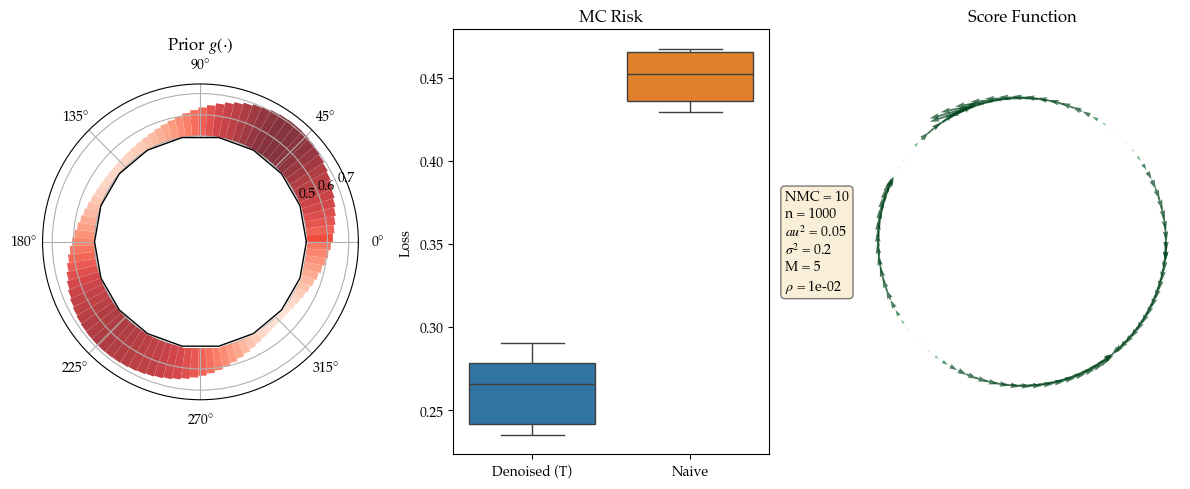

In [25]:
# ----- visualization ------------------------------------------------------------------------------------------------------- 
import seaborn as sns
data_to_plot = pd.DataFrame({
    'Denoised (T)': (loss_T_all**.5).flatten(), 
    'Naive': (loss_N_all**.5).flatten()}
    )
fig = plt.figure(figsize=(12, 5))
# Left plot: Prior ------------------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 1, polar=True)
ax1.bar(grid_I, f_scale*hat_f_pos, width=2*np.pi/res, bottom=bottom, color=plt.colormaps['Reds'](norm_hat_f), alpha=0.8, align='edge')
ax1.set_title('Prior $g(\cdot )$')
ax1.plot(angs_fill, bottom_fill*np.ones_like(angs_fill), color='black', linewidth=1., zorder=5)
ax1.fill_between(angs_fill, np.zeros_like(angs_fill), bottom_fill, color='white', zorder=4)
# Central plot: Boxplot ------------------------------------------------------------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
sns.boxplot(data=data_to_plot, ax=ax2)
ax2.set_ylabel('Loss')
ax2.set_title('MC Risk')
# Add text box with parameters ----------------------------------------------------------------------------------------------
textstr = '\n'.join((
    f'NMC = {NMC}',
    f'n = {n_samples}',
    f'$\tau^2$ = {tau2}',
    f'$\sigma^2$ = {sigma2}',
    f'M = {M}',
    f'$\\rho$ = {rho:.0e}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(1.05, 0.5, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='center', bbox=props)
# Right plot: Quiver  ------------------------------------------------------------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3)
X = circle.random_riemannian_normal(Theta, 1./sigma2, 1000)
grid, hat_f, hat_grad_f = density_estimate('S1', X, M,  grid)
hat_score = hat_grad_f / np.maximum(hat_f, 1e-2)
ax3.quiver( grid[:,0], grid[:,1], hat_score * grid[:,1], -hat_score * grid[:,0],
             alpha=0.7,
            color=plt.cm.Greens(np.abs(hat_score )),
            # width=0.005, headwidth=15, headlength=4
)
ax3.set_title('Score Function')
ax3.axis('equal')
ax3.set_axis_off()
plt.tight_layout()
plt.show()